<div style="color:white;
           display:fill;
           text-align: center;
           border-radius:5px;
           background-color:#1E90FF;
           font-size:110%;
           font-family:cursive;
           letter-spacing:0.5px">

<h1 style="padding: 20px; color:white;">Data Analysis</h1>
</div>


Dataset comes from [HERE](https://www.kaggle.com/datasets/bukolafatunde/personal-finance).

<div style="color:white;
           display:fill;
           text-align: center;
           border-radius:5px;
           background-color:#87CEEB;
           font-size:90%;
           font-family:cursive;
           letter-spacing:0.5px">

<h2 style="padding: 10px; color:white;">1. Install & Load Data</h2>
</div>


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/personal-finance/personal_transactions.csv
/kaggle/input/personal-finance/Budget.csv


In [2]:
df_budget = pd.read_csv("/kaggle/input/personal-finance/Budget.csv")
df = pd.read_csv("/kaggle/input/personal-finance/personal_transactions.csv")
df.head()

,Date,Description,Amount,Transaction Type,Category,Account Name
0,01/01/2018,Amazon,11.11,debit,Shopping,Platinum Card
1,01/02/2018,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking
2,01/02/2018,Thai Restaurant,24.22,debit,Restaurants,Silver Card
3,01/03/2018,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card
4,01/04/2018,Netflix,11.76,debit,Movies & DVDs,Platinum Card


In [3]:
df_budget.head()

,Category,Budget
0,Alcohol & Bars,50
1,Auto Insurance,75
2,Coffee Shops,15
3,Electronics & Software,0
4,Entertainment,25


In [4]:
df_budget.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  19 non-null     object
 1   Budget    19 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 436.0+ bytes


In [5]:
df_budget.isnull().sum()

Category    0
Budget      0
dtype: int64

In [6]:
df_budget.duplicated().sum()

0

In [7]:
df_budget['Category'].value_counts()

Category
Alcohol & Bars            1
Internet                  1
Television                1
Shopping                  1
Restaurants               1
Music                     1
Movies & DVDs             1
Mortgage & Rent           1
Mobile Phone              1
Home Improvement          1
Auto Insurance            1
Haircut                   1
Groceries                 1
Gas & Fuel                1
Fast Food                 1
Entertainment             1
Electronics & Software    1
Coffee Shops              1
Utilities                 1
Name: count, dtype: int64

In [8]:
df_budget['Category'].nunique()

19

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              806 non-null    object 
 1   Description       806 non-null    object 
 2   Amount            806 non-null    float64
 3   Transaction Type  806 non-null    object 
 4   Category          806 non-null    object 
 5   Account Name      806 non-null    object 
dtypes: float64(1), object(5)
memory usage: 37.9+ KB


In [10]:
df.describe()

,Amount
count,806.000000
mean,273.391489
std,667.630374
min,1.750000
25%,15.687500
50%,37.480000
75%,117.680000
max,9200.000000


In [11]:
df.describe(include='object')

,Date,Description,Transaction Type,Category,Account Name
count,806,806,806,806,806
unique,432,65,2,22,3
top,12/18/2018,Credit Card Payment,debit,Credit Card Payment,Platinum Card
freq,7,143,688,143,366


<div style="color:white;
           display:fill;
           text-align: center;
           border-radius:5px;
           background-color:#87CEEB;
           font-size:90%;
           font-family:cursive;
           letter-spacing:0.5px">

<h2 style="padding: 10px; color:white;">2. Clean Data</h2>
</div>

In [12]:
print(f"* Print the oldest date in the dataset: {df['Date'].min()}\n")
print(f"* Print the latest date in the dataset: {df['Date'].max()}\n")

* Print the oldest date in the dataset: 01/01/2018

* Print the latest date in the dataset: 12/29/2018



In [13]:
df.isnull().sum()

Date                0
Description         0
Amount              0
Transaction Type    0
Category            0
Account Name        0
dtype: int64

In [14]:
df.duplicated().sum()

0

In [15]:
df.columns

Index(['Date', 'Description', 'Amount', 'Transaction Type', 'Category',
       'Account Name'],
      dtype='object')

In [16]:
# Check unique values in categorical columns
cat_cols = ['Description', 'Transaction Type', 'Category', 'Account Name']
for col in cat_cols:
    print(f"Print the unique values in the {col} column: {df[col].value_counts()}\n")

Print the unique values in the Description column: Description
Credit Card Payment    143
Grocery Store          103
Amazon                  59
Biweekly Paycheck       46
Hardware Store          34
                      ... 
Irish Pub                1
Tiny Deli                1
Chevron                  1
Japanese Restaurant      1
Sheetz                   1
Name: count, Length: 65, dtype: int64

Print the unique values in the Transaction Type column: Transaction Type
debit     688
credit    118
Name: count, dtype: int64

Print the unique values in the Category column: Category
Credit Card Payment       143
Groceries                 105
Restaurants                81
Utilities                  63
Shopping                   60
Gas & Fuel                 52
Paycheck                   46
Home Improvement           36
Coffee Shops               31
Alcohol & Bars             25
Music                      21
Mobile Phone               21
Mortgage & Rent            21
Internet                  

In [17]:
df['Category'].nunique()

22

In [18]:
df.columns = df.columns.str.replace(" ", "_") #Standardize column

In [19]:
# Standardize 'Category' and 'Description' (Text Cleaning)
# Convert to lowercase and strip whitespace to ensure consistency.
# This helps in grouping and analysis, preventing issues like "Groceries" vs "groceries ".
df['Description'] = df['Description'].str.lower().str.strip().str.replace(" ", "")
df['Category'] = df['Category'].str.lower().str.strip().str.replace(" ", "")
df['Transaction_Type'] = df['Transaction_Type'].str.lower().str.strip().str.replace(" ", "")
df['Account_Name'] = df['Account_Name'].str.lower().str.strip().str.replace(" ", "")
print("\nAfter standardizing text columns (lowercase, strip whitespace):")
print(df[['Description', 'Category', 'Transaction_Type', 'Account_Name']].head())



After standardizing text columns (lowercase, strip whitespace):
         Description           Category Transaction_Type  Account_Name
0             amazon           shopping            debit  platinumcard
1    mortgagepayment      mortgage&rent            debit      checking
2     thairestaurant        restaurants            debit    silvercard
3  creditcardpayment  creditcardpayment           credit  platinumcard
4            netflix        movies&dvds            debit  platinumcard


In [20]:
df.head()

,Date,Description,Amount,Transaction_Type,Category,Account_Name
0,01/01/2018,amazon,11.11,debit,shopping,platinumcard
1,01/02/2018,mortgagepayment,1247.44,debit,mortgage&rent,checking
2,01/02/2018,thairestaurant,24.22,debit,restaurants,silvercard
3,01/03/2018,creditcardpayment,2298.09,credit,creditcardpayment,platinumcard
4,01/04/2018,netflix,11.76,debit,movies&dvds,platinumcard


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              806 non-null    object 
 1   Description       806 non-null    object 
 2   Amount            806 non-null    float64
 3   Transaction_Type  806 non-null    object 
 4   Category          806 non-null    object 
 5   Account_Name      806 non-null    object 
dtypes: float64(1), object(5)
memory usage: 37.9+ KB


Text(0.5, 1.0, 'Boxplot of Amount')

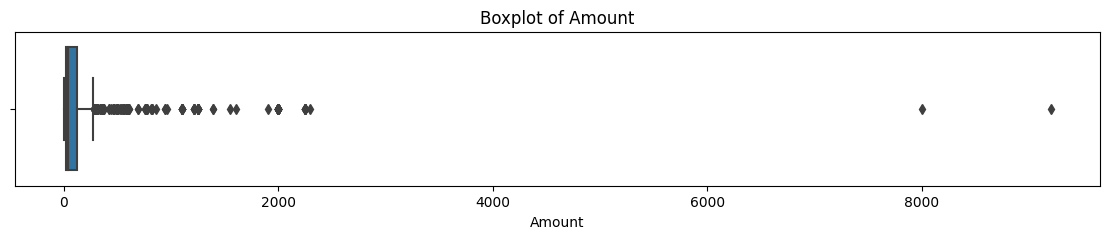

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (14, 2))
sns.boxplot(x=df['Amount'])
plt.title("Boxplot of Amount")


IQR: 101.9925
Lower bound for outliers: -137.30125
Upper bound for outliers: 270.66875000000005

'Amount' column descriptive statistics after capping outliers:
count    806.000000
mean      89.564828
std      100.376989
min        1.750000
25%       15.687500
50%       37.480000
75%      117.680000
max      270.668750
Name: Amount, dtype: float64


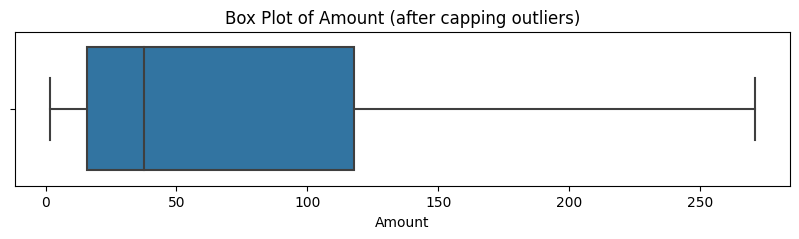

In [23]:
# Handling Outliers in 'Amount'
# Financial data often has legitimate large transactions (e.g., house down payment, large bonus)
# that are *not* errors but can skew predictive models for day-to-day spending.
# A common strategy is to cap or "winsorize" extreme values rather than remove them entirely,
# especially if they represent significant, albeit infrequent, events.
# We'll use the Interquartile Range (IQR) method as it's robust to skewed data.

# Separate income and expenses for outlier detection if 'Amount' contains both positive/negative
# For personal finance, it's often better to treat income and expenses separately
# or consider absolute values for outlier detection if the sign doesn't matter for the outlier definition.
# Here, we'll treat them as one for simplicity, but note this could be refined.

# Calculate IQR for the 'Amount' column
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds using the 1.5 * IQR rule
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nIQR: {IQR}")
print(f"Lower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")

# Option A: Capping/Winsorization (Recommended for financial data)
# This keeps the data points but limits their extreme values to the defined bounds.
# This is often preferred for financial data as very large/small transactions
# might be legitimate, even if infrequent, and removing them loses information.
df_cleaned_capped = df.copy() # Create a copy to show different approaches
df_cleaned_capped['Amount'] = np.where(df_cleaned_capped['Amount'] < lower_bound, lower_bound, df_cleaned_capped['Amount'])
df_cleaned_capped['Amount'] = np.where(df_cleaned_capped['Amount'] > upper_bound, upper_bound, df_cleaned_capped['Amount'])

print("\n'Amount' column descriptive statistics after capping outliers:")
print(df_cleaned_capped['Amount'].describe())

plt.figure(figsize=(10, 2))
sns.boxplot(x=df_cleaned_capped['Amount'])
plt.title('Box Plot of Amount (after capping outliers)')
plt.show()

# Option B: Removal (Use with caution for financial data)
# This removes rows where 'Amount' falls outside the bounds.
# Only use if you're certain the outliers are errors or irrelevant to your core analysis.
# For personal finance, a large one-time income/expense could be an outlier but still relevant.
# df_cleaned_removed = df[(df['Amount'] >= lower_bound) & (df['Amount'] <= upper_bound)].copy()
# print("\nDataFrame shape after removing outliers:", df_cleaned_removed.shape)
# print("\n'Amount' column descriptive statistics after removing outliers:")
# print(df_cleaned_removed['Amount'].describe())

#  Flag or Remove Outliers
# Option B: Flag outliers (add a column)
#df_cleaned_removed['is_outlier'] = ~df_cleaned_removed['Amount'].between(lower_bound, upper_bound)

# Optional: Log how many were detected
#num_outliers = df_cleaned_removed['is_outlier'].sum()
#print(f"Detected {num_outliers} outliers in 'Amount' column.")

# Optional: Review outliers before removing
# print(df_cleaned_removed[df_cleaned_removed['is_outlier'] == True])

In [24]:
df_cleaned_capped['Category'].value_counts()

Category
creditcardpayment       143
groceries               105
restaurants              81
utilities                63
shopping                 60
gas&fuel                 52
paycheck                 46
homeimprovement          36
coffeeshops              31
alcohol&bars             25
music                    21
mobilephone              21
mortgage&rent            21
internet                 21
movies&dvds              18
autoinsurance            18
fastfood                 16
haircut                  13
television                8
electronics&software      4
food&dining               2
entertainment             1
Name: count, dtype: int64

<div style="color:white;
           display:fill;
           text-align: center;
           border-radius:5px;
           background-color:#87CEEB;
           font-size:90%;
           font-family:cursive;
           letter-spacing:0.5px">

<h2 style="padding: 10px; color:white;">3. Feature Engineering</h2>
</div>


In [25]:
# Feature Engineering (Highly recommended for predictive insights)
# While not strictly "cleaning," this is a crucial step for making your data useful for prediction.
df_feature = df_cleaned_capped.copy()
# Create 'Month' and 'Year' columns for time-series analysis
df_feature['Date'] = pd.to_datetime(df_feature['Date']) # Convert data type
df_feature['Month'] = df_feature['Date'].dt.month
df_feature['Year'] = df_feature['Date'].dt.year

# Create 'Day of Week' for potential weekly patterns
df_feature['DayOfWeek'] = df_feature['Date'].dt.dayofweek # Monday=0, Sunday=6

# Create 'Is_Weekend' for weekend spending patterns
df_feature['Is_Weekend'] = df_feature['Date'].dt.dayofweek >= 5

# Create a 'Net Amount' if 'Amount' combines income/expense, or handle them separately.
# A common approach for dashboarding is to have separate columns for Income and Expense amounts
# which makes aggregation and visualization easier.
df_feature['Income_Amount'] = df_feature.apply(lambda row: row['Amount'] if row['Transaction_Type'] == 'income' else 0, axis=1)
df_feature['Expense_Amount'] = df_feature.apply(lambda row: abs(row['Amount']) if row['Transaction_Type'] == 'expense' else 0, axis=1)

print("\n* Final cleaned DataFrame info:\n")
df_feature.info()
print("\n* DataFrame head after feature engineering:\n")
df_feature.head()


* Final cleaned DataFrame info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              806 non-null    datetime64[ns]
 1   Description       806 non-null    object        
 2   Amount            806 non-null    float64       
 3   Transaction_Type  806 non-null    object        
 4   Category          806 non-null    object        
 5   Account_Name      806 non-null    object        
 6   Month             806 non-null    int32         
 7   Year              806 non-null    int32         
 8   DayOfWeek         806 non-null    int32         
 9   Is_Weekend        806 non-null    bool          
 10  Income_Amount     806 non-null    int64         
 11  Expense_Amount    806 non-null    int64         
dtypes: bool(1), datetime64[ns](1), float64(1), int32(3), int64(2), object(4)
memory usage: 60.7+ KB

* D

,Date,Description,Amount,Transaction_Type,Category,Account_Name,Month,Year,DayOfWeek,Is_Weekend,Income_Amount,Expense_Amount
0,2018-01-01,amazon,11.11000,debit,shopping,platinumcard,1,2018,0,False,0,0
1,2018-01-02,mortgagepayment,270.66875,debit,mortgage&rent,checking,1,2018,1,False,0,0
2,2018-01-02,thairestaurant,24.22000,debit,restaurants,silvercard,1,2018,1,False,0,0
3,2018-01-03,creditcardpayment,270.66875,credit,creditcardpayment,platinumcard,1,2018,2,False,0,0
4,2018-01-04,netflix,11.76000,debit,movies&dvds,platinumcard,1,2018,3,False,0,0


<div style="color:white;
           display:fill;
           text-align: center;
           border-radius:5px;
           background-color:#87CEEB;
           font-size:90%;
           font-family:cursive;
           letter-spacing:0.5px">

<h2 style="padding: 10px; color:white;">4. Exploratory Data Analysis (EDA)</h2>
</div>


**1. Core Descriptive Insights (Dashboard Foundation)**

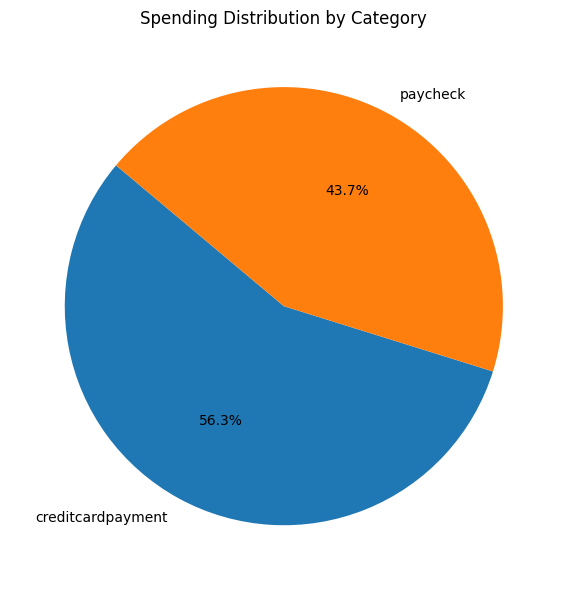

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

df = df_cleaned_capped.copy()
# Ensure correct data types
df['Date'] = pd.to_datetime(df['Date'])
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# Add Month-Year column for grouping
df['Month'] = df['Date'].dt.to_period('M')

# Separate income and expenses
df_income = df[df['Transaction_Type'].str.lower() == 'debit']
df_expense = df[df['Transaction_Type'].str.lower() == 'credit']

# ----------------------------
# 1. Pie Chart: Spending Habits by Category
# ----------------------------
category_expense = df_expense.groupby('Category')['Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
category_expense.plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Spending Distribution by Category')
plt.ylabel('')
plt.tight_layout()
plt.show()

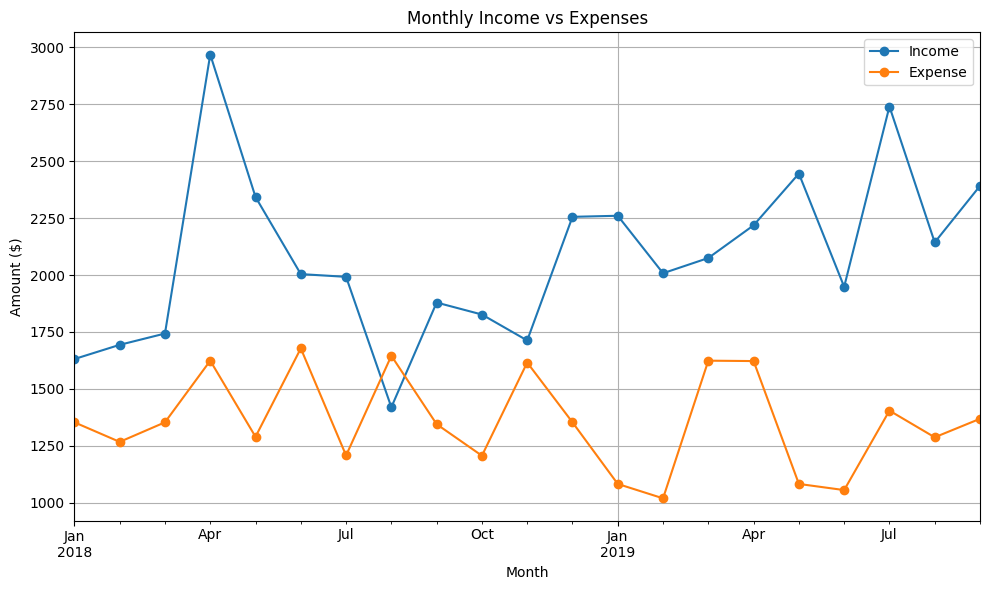

In [27]:
# ----------------------------
# 2. Line Chart: Income vs Expense Trend
# ----------------------------
monthly_income = df_income.groupby('Month')['Amount'].sum()
monthly_expense = df_expense.groupby('Month')['Amount'].sum()

plt.figure(figsize=(10, 6))
monthly_income.plot(label='Income', marker='o')
monthly_expense.plot(label='Expense', marker='o')
plt.title('Monthly Income vs Expenses')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

💰 Saving Rate for 2019-09: 42.77%


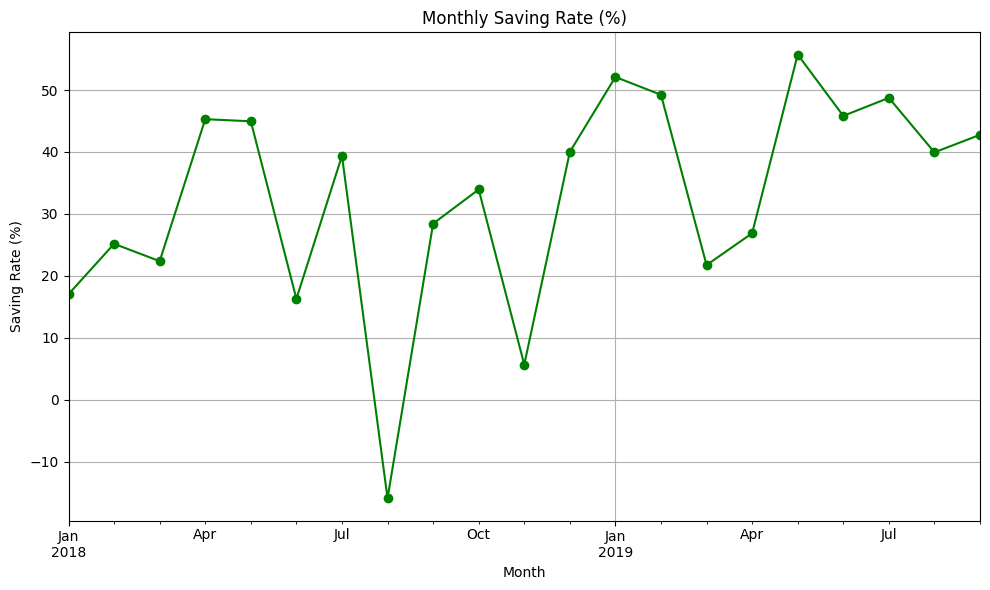

In [28]:
# ----------------------------
# 3. Saving Rate: KPI & Line Chart
# ----------------------------
monthly_summary = pd.DataFrame({
    'Income': monthly_income,
    'Expense': monthly_expense
})
monthly_summary['Savings'] = monthly_summary['Income'] - monthly_summary['Expense']
monthly_summary['Saving Rate (%)'] = (monthly_summary['Savings'] / monthly_summary['Income']) * 100

# KPI
latest_month = monthly_summary.index[-1]
latest_rate = monthly_summary.loc[latest_month, 'Saving Rate (%)']
print(f"💰 Saving Rate for {latest_month}: {latest_rate:.2f}%")

# Line chart
plt.figure(figsize=(10, 6))
monthly_summary['Saving Rate (%)'].plot(marker='o', color='green')
plt.title('Monthly Saving Rate (%)')
plt.ylabel('Saving Rate (%)')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_13/1609128103.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_expense['Z_score'] = zscore(df_expense['Amount'])
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


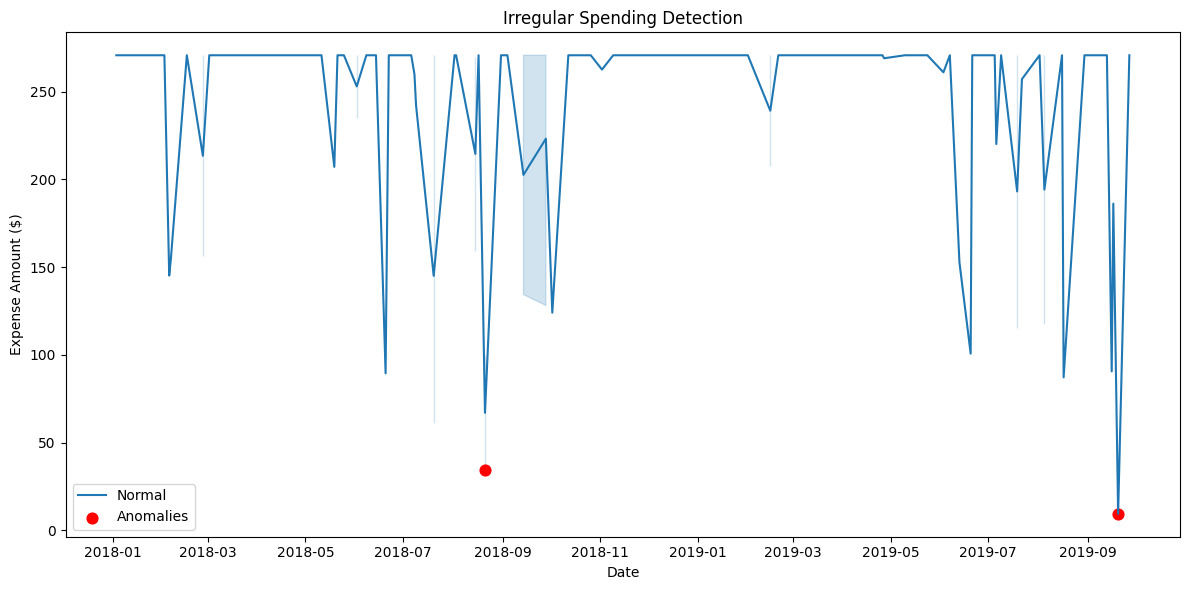

In [29]:
# ----------------------------
# 4. Irregular Spending Detection (Z-score Method)
# ----------------------------
# Calculate Z-score for expenses
df_expense['Z_score'] = zscore(df_expense['Amount'])

# Flag anomalies
threshold = 3  # Adjustable
df_anomalies = df_expense[df_expense['Z_score'].abs() > threshold]

# Plot with anomalies highlighted
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_expense, x='Date', y='Amount', label='Normal')
plt.scatter(df_anomalies['Date'], df_anomalies['Amount'], color='red', label='Anomalies', s=60)
plt.title('Irregular Spending Detection')
plt.xlabel('Date')
plt.ylabel('Expense Amount ($)')
plt.legend()
plt.tight_layout()
plt.show()

**2. Predictive Insights (Forecasting the Future)**

In [30]:
pip install prophet matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [31]:
df['Month'].dtypes

period[M]

18:30:56 - cmdstanpy - INFO - Chain [1] start processing
18:30:57 - cmdstanpy - INFO - Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


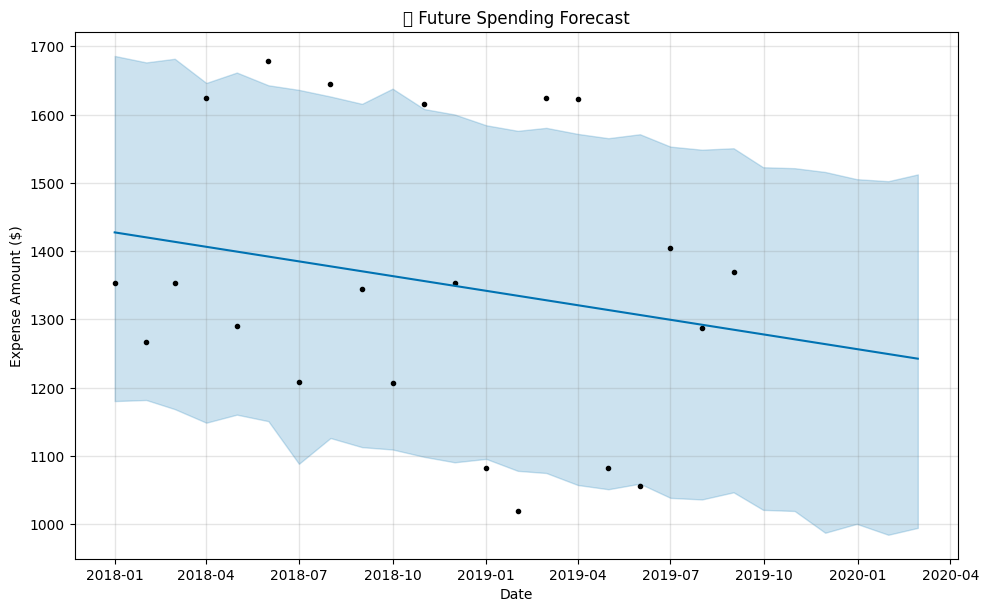

In [32]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# --- 1. Preprocess for Time-Series Forecasting ---
# Ensure datetime format
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M').dt.to_timestamp() # Covert data type

# --- 1. Preprocess for Time-Series Forecasting ---
# Group monthly expenses and income
monthly_expense = df[df['Transaction_Type'].str.lower() == 'credit'].groupby('Month')['Amount'].sum().reset_index()
monthly_income = df[df['Transaction_Type'].str.lower() == 'debit'].groupby('Month')['Amount'].sum().reset_index()

# --- 2. Future Spending Forecast (using Prophet) ---
spend_df = monthly_expense.rename(columns={'Month': 'ds', 'Amount': 'y'})

model_spend = Prophet()
model_spend.fit(spend_df)

future_spend = model_spend.make_future_dataframe(periods=6, freq='M')
forecast_spend = model_spend.predict(future_spend)

# Plot
model_spend.plot(forecast_spend)
plt.title('📉 Future Spending Forecast')
plt.xlabel('Date')
plt.ylabel('Expense Amount ($)')
plt.show()

🎯 At your current savings rate ($1071.48/month), you'll reach $5000 in about -9 months.


/tmp/ipykernel_13/3049373576.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  projection_dates = pd.date_range(start=summary['Month'].iloc[-1] + pd.DateOffset(months=1), periods=months_needed + 1, freq='M')
/tmp/ipykernel_13/3049373576.py:27: UserWarning: Glyph 127974 (\N{BANK}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127974 (\N{BANK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


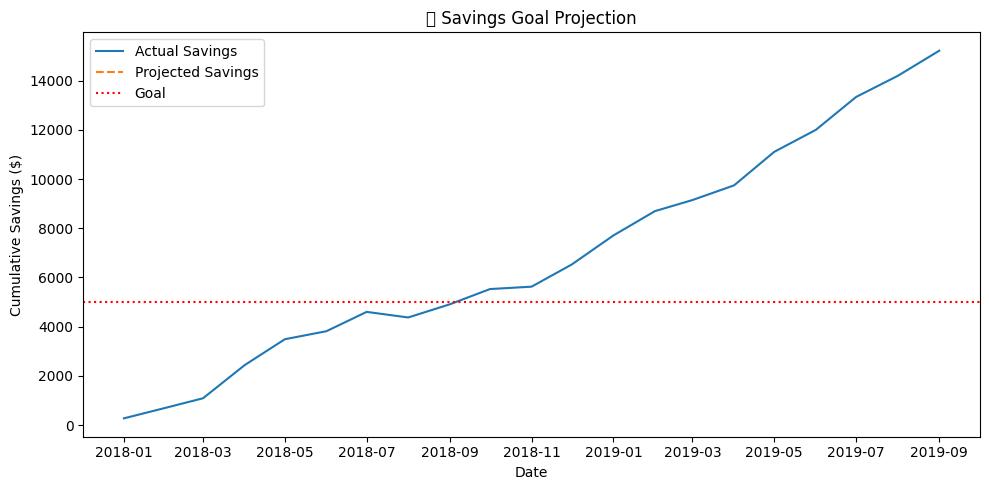

In [33]:
# --- 3. Savings Goal Projection ---
# Merge monthly income and expense
summary = pd.merge(monthly_income, monthly_expense, on='Month', how='outer', suffixes=('_income', '_expense')).fillna(0)
summary['Savings'] = summary['Amount_income'] - summary['Amount_expense']
summary['Cumulative Savings'] = summary['Savings'].cumsum()

# Define savings goal
savings_goal = 5000
current_savings = summary['Cumulative Savings'].iloc[-1]
avg_monthly_savings = summary['Savings'].tail(3).mean()
months_needed = int((savings_goal - current_savings) / avg_monthly_savings)

print(f"🎯 At your current savings rate (${avg_monthly_savings:.2f}/month), you'll reach ${savings_goal} in about {months_needed} months.")

# Projection plot
projected_savings = [current_savings + i * avg_monthly_savings for i in range(months_needed + 1)]
projection_dates = pd.date_range(start=summary['Month'].iloc[-1] + pd.DateOffset(months=1), periods=months_needed + 1, freq='M')

plt.figure(figsize=(10, 5))
plt.plot(summary['Month'], summary['Cumulative Savings'], label='Actual Savings')
plt.plot(projection_dates, projected_savings, linestyle='--', label='Projected Savings')
plt.axhline(y=savings_goal, color='r', linestyle=':', label='Goal')
plt.title('🏦 Savings Goal Projection')
plt.xlabel('Date')
plt.ylabel('Cumulative Savings ($)')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_13/1719213623.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=summary['Month'].iloc[-1] + pd.DateOffset(months=1), periods=future_months, freq='M')
/tmp/ipykernel_13/1719213623.py:16: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


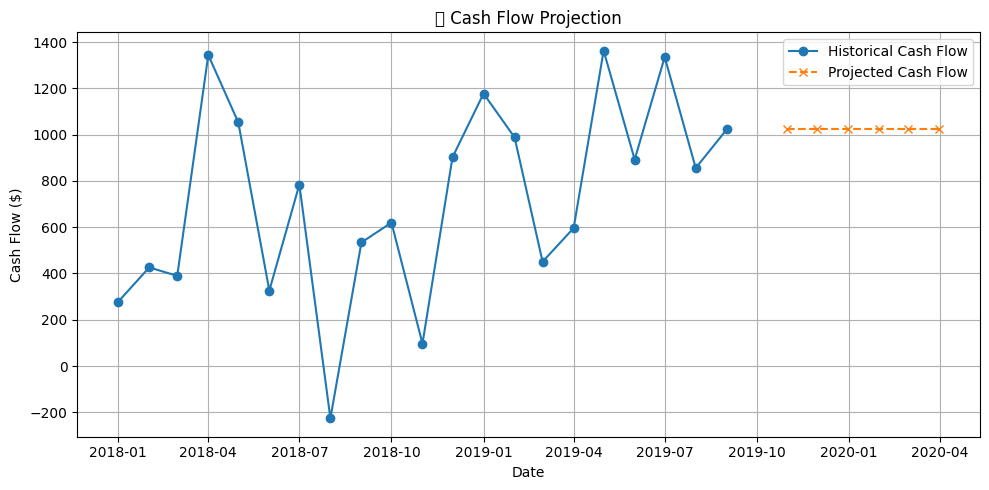

In [34]:
# --- 4. Cash Flow Projection ---
summary['Cash Flow'] = summary['Amount_income'] - summary['Amount_expense']
cash_flow_avg = summary['Cash Flow'].tail(3).mean()
future_months = 6
cash_projection = [summary['Cash Flow'].iloc[-1] + i * 0 for i in range(1, future_months + 1)]  # assuming flat future
future_dates = pd.date_range(start=summary['Month'].iloc[-1] + pd.DateOffset(months=1), periods=future_months, freq='M')

plt.figure(figsize=(10, 5))
plt.plot(summary['Month'], summary['Cash Flow'], marker='o', label='Historical Cash Flow')
plt.plot(future_dates, cash_projection, linestyle='--', marker='x', label='Projected Cash Flow')
plt.title('💸 Cash Flow Projection')
plt.xlabel('Date')
plt.ylabel('Cash Flow ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_13/904785460.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  debt_dates = pd.date_range(start=summary['Month'].iloc[-1] + pd.DateOffset(months=1), periods=months_to_clear_debt + 1, freq='M')
/tmp/ipykernel_13/904785460.py:16: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


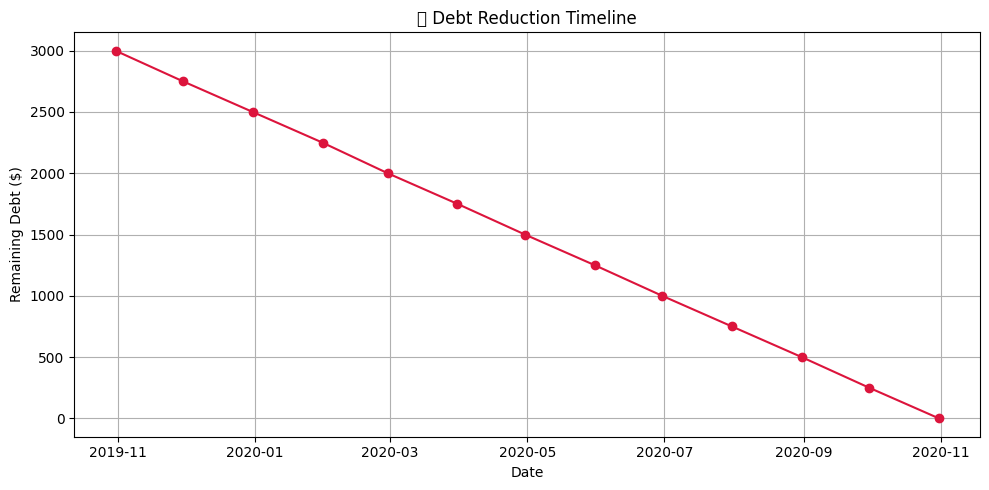

🧾 At $250/month, your $3000 debt will be cleared in 12 months.


In [35]:
# --- 5. Debt Reduction Timeline (Assumed Logic) ---
# Assumption: Add a known debt balance
debt_balance = 3000
monthly_debt_payment = 250  # assumption or user input
months_to_clear_debt = int(debt_balance / monthly_debt_payment)

debt_remaining = [debt_balance - i * monthly_debt_payment for i in range(months_to_clear_debt + 1)]
debt_dates = pd.date_range(start=summary['Month'].iloc[-1] + pd.DateOffset(months=1), periods=months_to_clear_debt + 1, freq='M')

plt.figure(figsize=(10, 5))
plt.plot(debt_dates, debt_remaining, marker='o', color='crimson')
plt.title('📉 Debt Reduction Timeline')
plt.xlabel('Date')
plt.ylabel('Remaining Debt ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"🧾 At ${monthly_debt_payment}/month, your $3000 debt will be cleared in {months_to_clear_debt} months.")

/tmp/ipykernel_13/3725160760.py:30: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


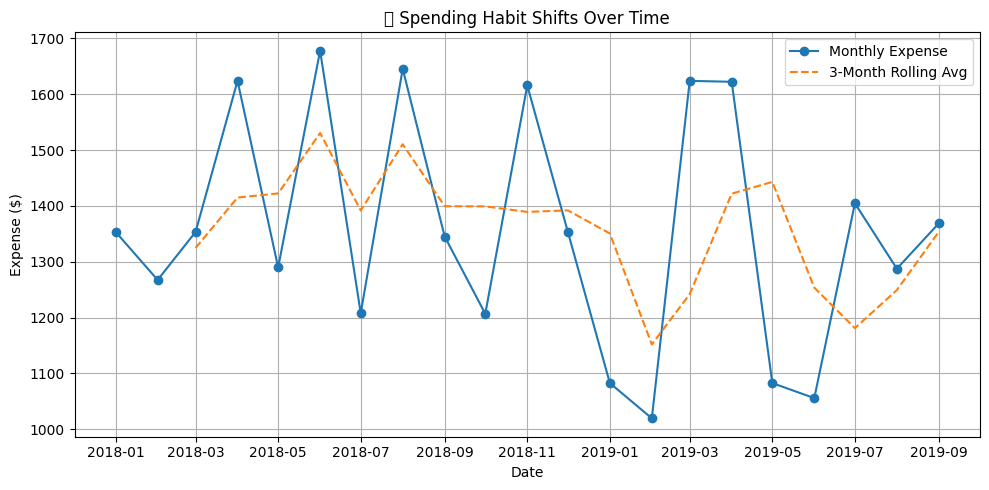

🔍 Spending change (%) per month:
            Expense Change %
Month                       
2018-02-01         -6.351491
2018-03-01          6.782265
2018-04-01         20.000000
2018-05-01        -20.582200
2018-06-01         30.100193
2018-07-01        -28.027629
2018-08-01         36.257817
2018-09-01        -18.256455
2018-10-01        -10.291160
2018-11-01         33.906278
2018-12-01        -16.245901
2019-01-01        -20.000000
2019-02-01         -5.837278
2019-03-01         59.298709
2019-04-01         -0.105218
2019-05-01        -33.263114
2019-06-01         -2.492669
2019-07-01         33.058907
2019-08-01         -8.342877
2019-09-01          6.315364


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Separate income and expenses
df_income = df[df['Transaction_Type'].str.lower() == 'debit']
df_expense = df[df['Transaction_Type'].str.lower() == 'credit']

# Monthly summaries
monthly_expense = df_expense.groupby('Month')['Amount'].sum().rename('Expense')
monthly_income = df_income.groupby('Month')['Amount'].sum().rename('Income')
summary = pd.concat([monthly_income, monthly_expense], axis=1).fillna(0)
summary['Savings'] = summary['Income'] - summary['Expense']
summary['Saving Rate (%)'] = (summary['Savings'] / summary['Income'].replace(0, np.nan)) * 100

# --------------------------------
# 1. Spending Habit Shifts
# --------------------------------
# Calculate rolling mean of expenses
summary['Expense Rolling Mean'] = summary['Expense'].rolling(window=3).mean()

plt.figure(figsize=(10, 5))
plt.plot(summary.index, summary['Expense'], label='Monthly Expense', marker='o')
plt.plot(summary.index, summary['Expense Rolling Mean'], label='3-Month Rolling Avg', linestyle='--')
plt.title('🧠 Spending Habit Shifts Over Time')
plt.xlabel('Date')
plt.ylabel('Expense ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional Insight: Percent change in spending
summary['Expense Change %'] = summary['Expense'].pct_change() * 100
print("🔍 Spending change (%) per month:")
print(summary[['Expense Change %']].dropna())


In [37]:
summary['Expense'].describe()

count      21.000000
mean     1356.566726
std       210.517253
min      1019.476250
25%      1207.677500
50%      1353.343750
75%      1615.853750
max      1677.973750
Name: Expense, dtype: float64

In [38]:
# --------------------------------
# 2. Budget Adherence Prediction (Classification)
# --------------------------------
# Simulate a budget threshold (can be user-defined)
budget_limit = 1600
summary['Over Budget'] = (summary['Expense'] > budget_limit).astype(int)

# Features: income, savings, last month's behavior
summary['Lag_Expense'] = summary['Expense'].shift(1)
summary['Lag_Savings'] = summary['Savings'].shift(1)
summary.dropna(inplace=True)

# Model
X = summary[['Income', 'Lag_Expense', 'Lag_Savings']]
y = summary['Over Budget']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\n📊 Budget Adherence Risk Prediction Report:")
print(classification_report(y_test, y_pred))

# Feature importance
coefs = pd.Series(clf.coef_[0], index=X.columns)
print("\n📌 Feature Influence on Over-Budget Risk:")
print(coefs.sort_values(ascending=False))



📊 Budget Adherence Risk Prediction Report:
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.50      0.33      0.40         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6


📌 Feature Influence on Over-Budget Risk:
Income         0.001608
Lag_Savings   -0.000282
Lag_Expense   -0.003185
dtype: float64


In [39]:
summary['Over Budget'] = (summary['Expense'] > budget_limit).astype(int)
summary['Over Budget'].sum()

6

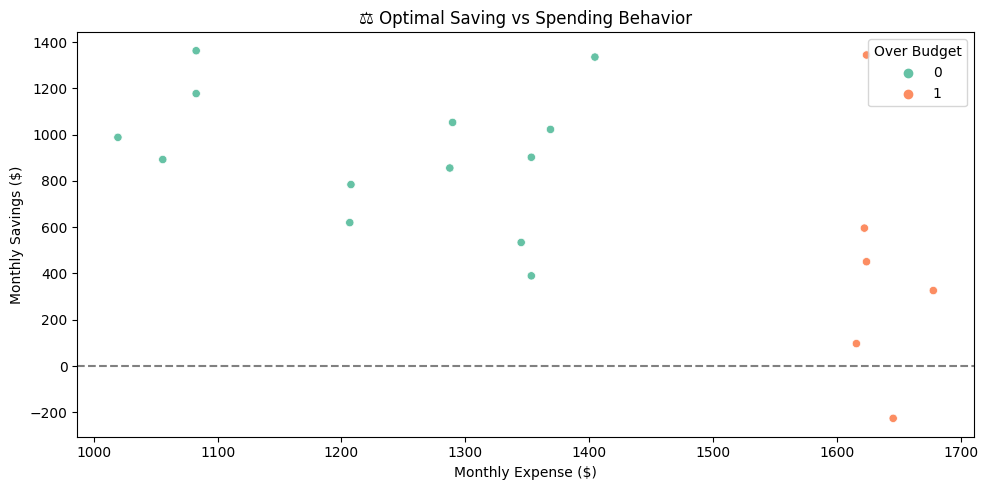


🔎 Saving Behavior Classification:
Balance Score
Optimal     16
Low          2
Moderate     1
Name: count, dtype: int64


In [40]:
# --------------------------------
# 3. Optimal Saving/Spending Balance
# --------------------------------
plt.figure(figsize=(10, 5))
sns.scatterplot(data=summary, x='Expense', y='Savings', hue='Over Budget', palette='Set2')
plt.title('⚖️ Optimal Saving vs Spending Behavior')
plt.xlabel('Monthly Expense ($)')
plt.ylabel('Monthly Savings ($)')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

# Optional: Define recommended range
summary['Balance Score'] = summary['Saving Rate (%)'].apply(
    lambda x: 'Optimal' if x >= 20 else ('Moderate' if x >= 10 else 'Low')
)

balance_counts = summary['Balance Score'].value_counts()
print("\n🔎 Saving Behavior Classification:")
print(balance_counts)

In [41]:
summary.describe()

,Income,Expense,Savings,Saving Rate (%),Expense Rolling Mean,Expense Change %,Over Budget,Lag_Expense,Lag_Savings
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,2125.081908,1361.430066,763.651842,33.857674,1359.026754,3.277633,0.315789,1356.092237,732.250395
std,365.037127,220.849036,434.361229,17.936803,102.618020,25.592892,0.477567,221.884084,436.146725
min,1419.408750,1019.476250,-226.146250,-15.932426,1151.831667,-33.263114,0.000000,1019.476250,-226.146250
25%,1913.880625,1207.191250,492.551250,24.619790,1289.123333,-17.251178,0.000000,1207.191250,438.561250
50%,2074.943750,1353.343750,856.030000,39.935620,1391.802083,-2.492669,0.000000,1345.135000,784.531250
75%,2301.618750,1619.078750,1037.929375,45.556120,1418.422500,25.050097,1.000000,1619.078750,1020.795000
max,2968.563750,1677.973750,1363.057500,55.732076,1530.580417,59.298709,1.000000,1677.973750,1363.057500


<div style="color:white;
           display:fill;
           text-align: center;
           border-radius:5px;
           background-color:#87CEEB;
           font-size:90%;
           font-family:cursive;
           letter-spacing:0.5px">

<h2 style="padding: 10px; color:white;">5. Forecasting Money Flow</h2>
</div>


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import numpy as np

# --- Preprocessing ---
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M').dt.to_timestamp()

# Separate income and expenses
df_income = df[df['Transaction_Type'].str.lower() == 'debit']
df_expense = df[df['Transaction_Type'].str.lower() == 'credit']

# ----------------------------
# 1. Establishing Baselines
# ----------------------------

# Monthly aggregates
monthly_income = df_income.groupby('Month')['Amount'].sum()
monthly_expense = df_expense.groupby(['Month', 'Category'])['Amount'].sum().unstack(fill_value=0)
monthly_total_expense = monthly_expense.sum(axis=1)
monthly_savings = monthly_income - monthly_total_expense
savings_rate = (monthly_savings / monthly_income) * 100

print("📊 Baseline Metrics:")
print(f"• Average Monthly Income: ${monthly_income.mean():.2f}")
print(f"• Average Monthly Savings Rate: {savings_rate.mean():.2f}%")
print(f"• Average Spend by Category:\n{monthly_expense.mean().round(2)}")


📊 Baseline Metrics:
• Average Monthly Income: $2081.02
• Average Monthly Savings Rate: 32.64%
• Average Spend by Category:
Category
creditcardpayment    763.67
paycheck             592.89
dtype: float64


/tmp/ipykernel_13/393673627.py:8: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


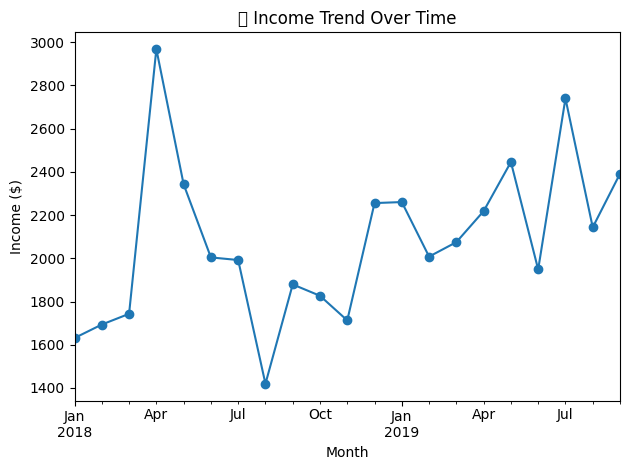

/tmp/ipykernel_13/393673627.py:16: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


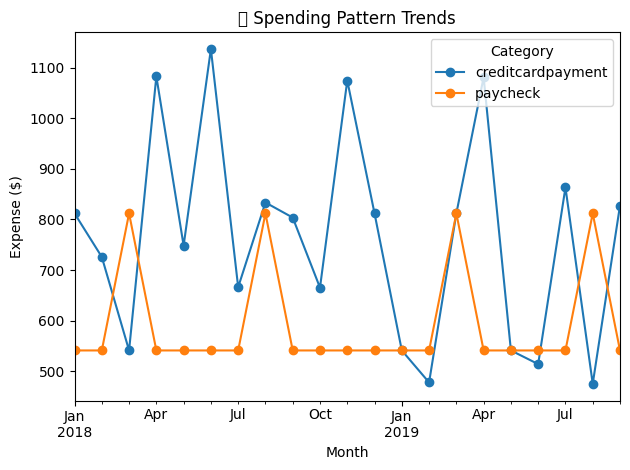

/tmp/ipykernel_13/393673627.py:22: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


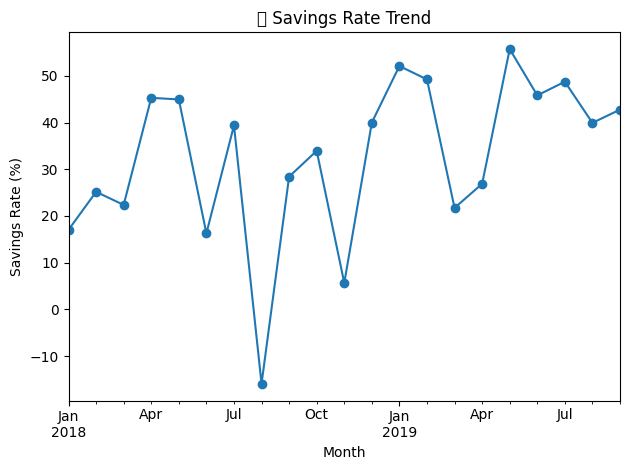

In [43]:
# ----------------------------
# 2. Identifying Trends
# ----------------------------

# Plot income trend
monthly_income.plot(title='📈 Income Trend Over Time', marker='o')
plt.ylabel('Income ($)')
plt.tight_layout()
plt.show()

# Trend in top 3 categories
top_categories = monthly_expense.mean().sort_values(ascending=False).head(3).index

monthly_expense[top_categories].plot(title='💳 Spending Pattern Trends', marker='o')
plt.ylabel('Expense ($)')
plt.tight_layout()
plt.show()

# Savings trend
savings_rate.plot(title='💰 Savings Rate Trend', marker='o')
plt.ylabel('Savings Rate (%)')
plt.tight_layout()
plt.show()


18:31:01 - cmdstanpy - INFO - Chain [1] start processing
18:31:01 - cmdstanpy - INFO - Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
/tmp/ipykernel_13/103824733.py:14: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_13/103824733.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


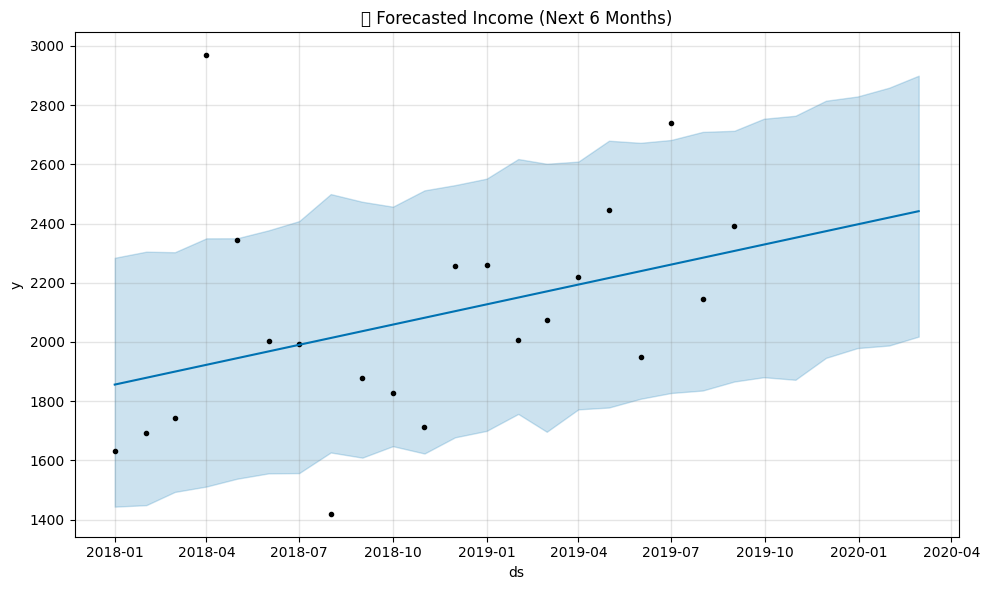

18:31:01 - cmdstanpy - INFO - Chain [1] start processing
18:31:01 - cmdstanpy - INFO - Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
/tmp/ipykernel_13/103824733.py:26: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_13/103824733.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


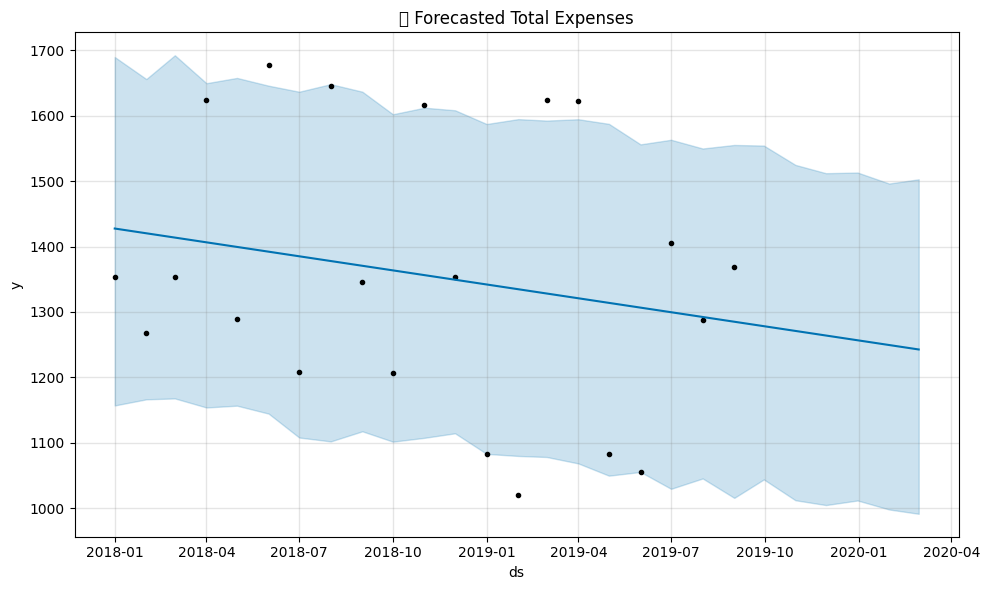

In [44]:
# ----------------------------
# 3. Time Series Forecasting (Prophet)
# ----------------------------

# Income forecasting
income_df = monthly_income.reset_index().rename(columns={'Month': 'ds', 'Amount': 'y'})
model_income = Prophet()
model_income.fit(income_df)
future_income = model_income.make_future_dataframe(periods=6, freq='M')
forecast_income = model_income.predict(future_income)

model_income.plot(forecast_income)
plt.title('🔮 Forecasted Income (Next 6 Months)')
plt.tight_layout()
plt.show()

# Repeat for expenses
total_expense_df = monthly_total_expense.reset_index().rename(columns={'Month': 'ds', 0: 'y', 'Amount': 'y'})
model_expense = Prophet()
model_expense.fit(total_expense_df)
future_expense = model_expense.make_future_dataframe(periods=6, freq='M')
forecast_expense = model_expense.predict(future_expense)

model_expense.plot(forecast_expense)
plt.title('🔮 Forecasted Total Expenses')
plt.tight_layout()
plt.show()

/tmp/ipykernel_13/2057746727.py:19: UserWarning: Glyph 128295 (\N{WRENCH}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128295 (\N{WRENCH}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


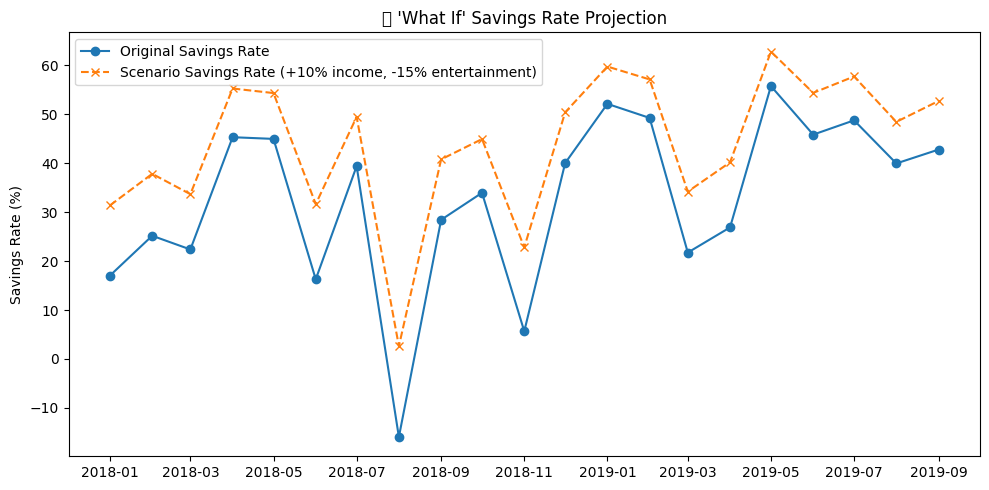

In [45]:
# ----------------------------
# 4. Scenario Simulation
# ----------------------------

# What if: income +10%, entertainment -15%
scenario_expense = monthly_expense.copy()
scenario_expense['creditcardpayment'] *= 0.85
scenario_total_expense = scenario_expense.sum(axis=1)
scenario_income = monthly_income * 1.10
scenario_savings = scenario_income - scenario_total_expense
scenario_savings_rate = (scenario_savings / scenario_income) * 100

plt.figure(figsize=(10, 5))
plt.plot(monthly_savings.index, savings_rate, label='Original Savings Rate', marker='o')
plt.plot(monthly_savings.index, scenario_savings_rate, label='Scenario Savings Rate (+10% income, -15% entertainment)', linestyle='--', marker='x')
plt.title("🔧 'What If' Savings Rate Projection")
plt.ylabel('Savings Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()



In [46]:
scenario_expense.head()

Category,creditcardpayment,paycheck
Month,,
2018-01-01,690.205313,541.33750
2018-02-01,617.141438,541.33750
2018-03-01,460.136875,812.00625
2018-04-01,920.273750,541.33750
2018-05-01,636.154875,541.33750


In [47]:
# ----------------------------
# 5. Behavioral Nudging/Alerts
# ----------------------------

# Alert logic (simple rules)
forecasted_expense_next_month = forecast_expense.iloc[-1]['yhat']
entertainment_avg = monthly_expense['creditcardpayment'].mean()
next_month_entertainment_proj = scenario_expense['creditcardpayment'].iloc[-1]  # Adjusted

alerts = []
if next_month_entertainment_proj > entertainment_avg * 1.2:
    alerts.append("⚠️ You're projected to exceed your Entertainment budget by over 20%!")

if forecast_income.iloc[-1]['yhat'] - forecasted_expense_next_month > 1000:
    alerts.append("🎯 You're on track for a strong surplus next month!")

if scenario_savings_rate.iloc[-1] > 25:
    alerts.append("🌟 Excellent! You're saving over 25% with this new plan.")

# Show alerts
print("\n📢 Behavioral Nudges & Alerts:")
for alert in alerts:
    print(alert)


📢 Behavioral Nudges & Alerts:
🎯 You're on track for a strong surplus next month!
🌟 Excellent! You're saving over 25% with this new plan.
